In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn as sk
import pandas as pd

# Data representation in scikit-learn

## data as a table

In [4]:
taxis = sns.load_dataset('taxis')
taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### features matrix
2d array of shape (n_samples, n_features). mostly work with numpy arrays or pandas dataframes.
sample: rows, features: columns

### target array
1d array of shape (n_samples,). mostly work with numpy arrays or pandas series. usually what we are predicting.

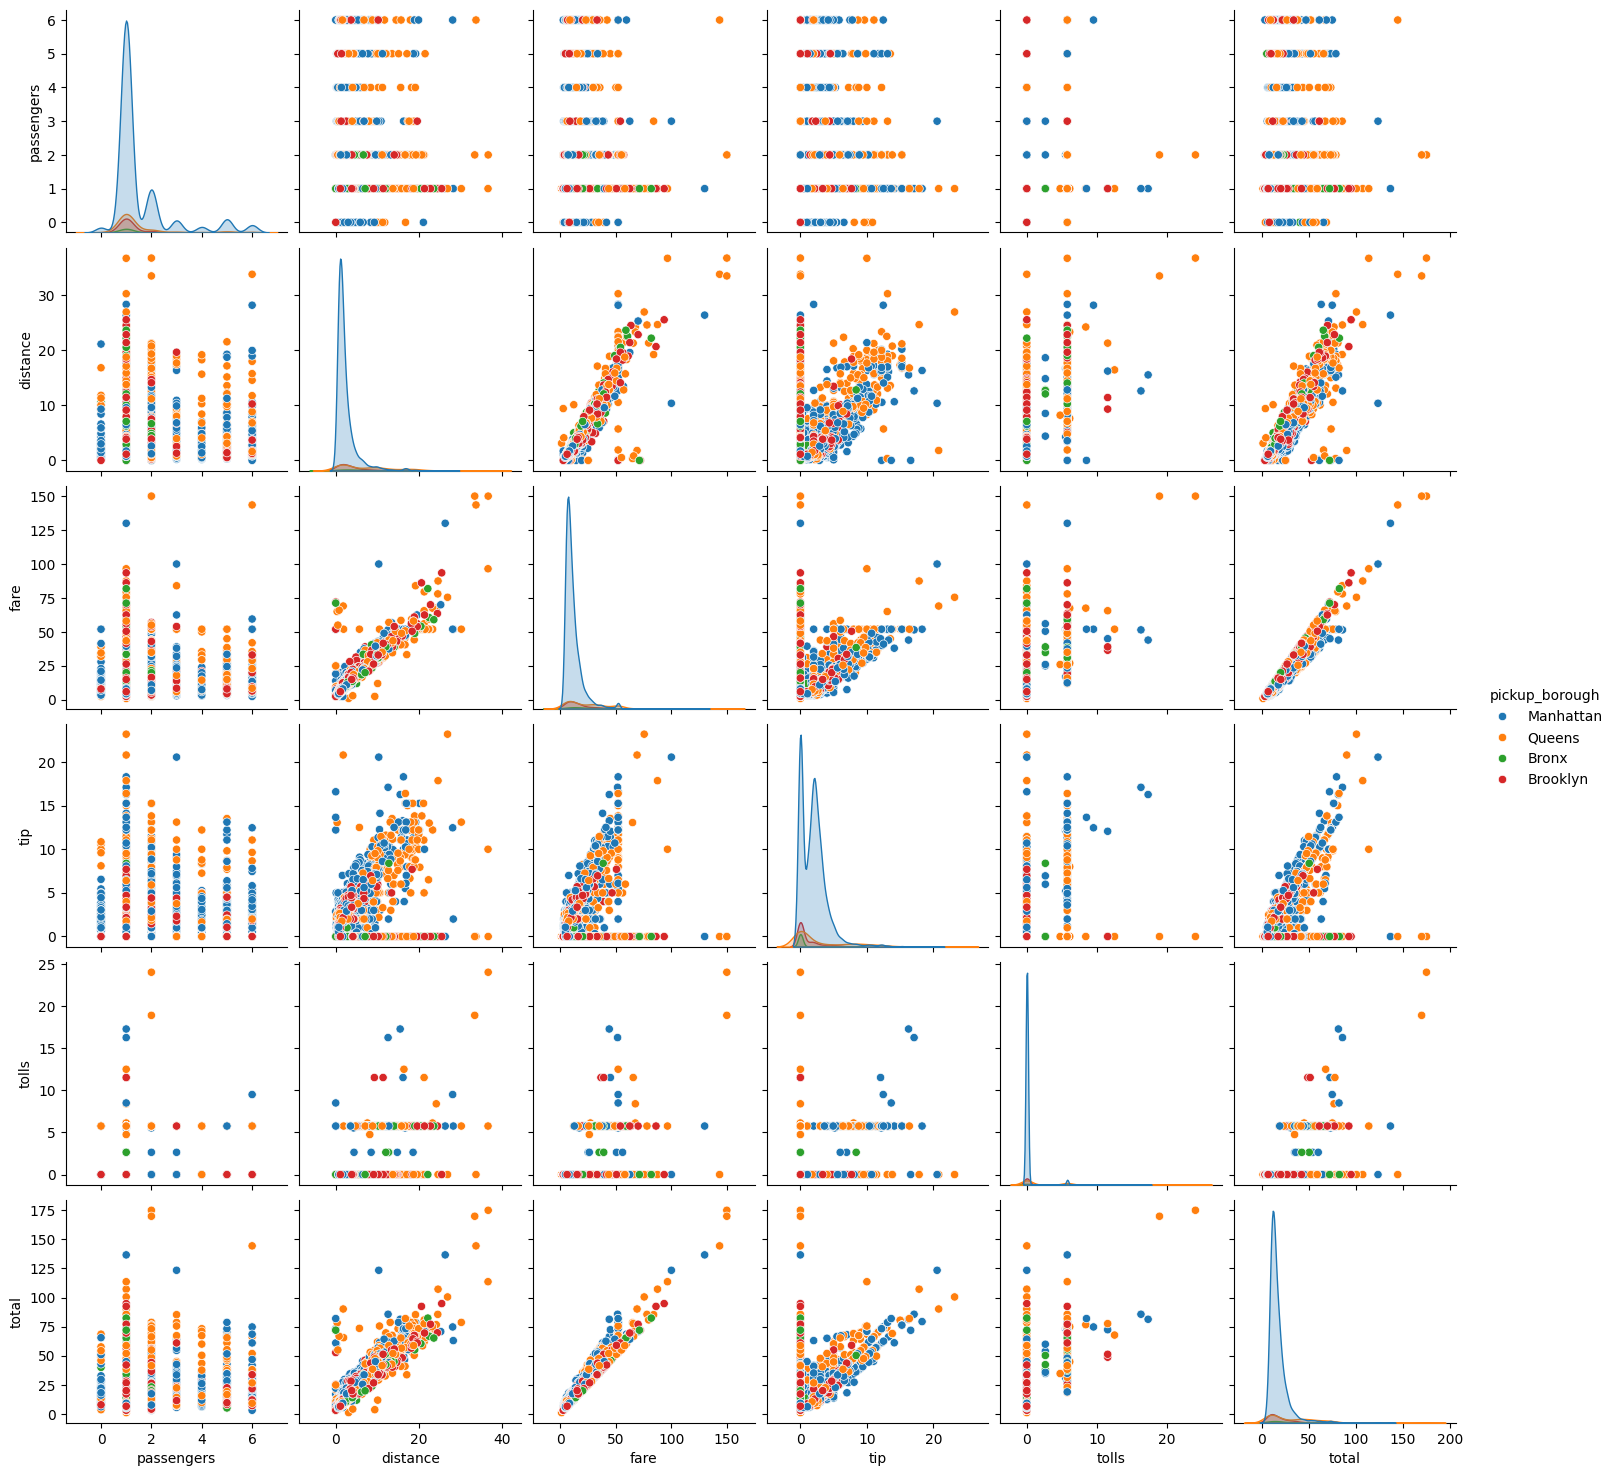

In [5]:
sns.pairplot(taxis, hue='pickup_borough')

In [6]:
print(taxis.shape)
passengers = taxis['passengers']
taxis.drop('passengers', axis=1, inplace=True)
print(passengers.shape, taxis.shape)

(6433, 14)
(6433,) (6433, 13)


# Scikit-learns estimator api

## basics of the api

## supervised learning example: simple linear regression

<Axes: >

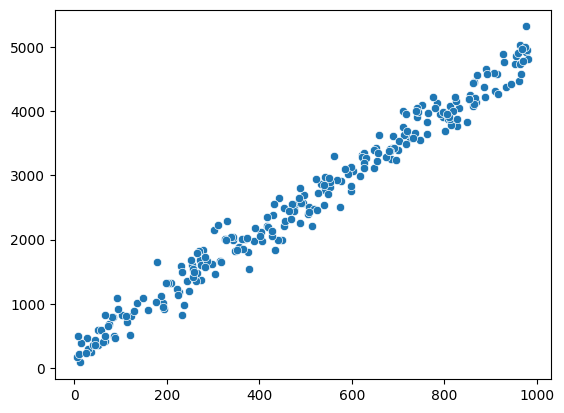

In [7]:
true_slope = 4.6
true_intercept = 300
y_scale = 200
num_samples = 250

x = np.random.rand(num_samples) * 1000
y = true_slope * x + true_intercept + np.random.randn(num_samples) * y_scale
sns.scatterplot(x=x, y=y)

### choose a class model

In [8]:
# choose a class model
from sklearn.linear_model import LinearRegression

# choose model hyperparameters
model = LinearRegression(copy_X=True, n_jobs=-1)

# arrange data to features matrix and target vector
X = x.reshape(-1, 1)

#fit the model to the data
model.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4.67]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,260.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4465.94]


model slope: 4.67, model intercept: 260.75
true slope: 4.60, true intercept: 300.00


<Axes: >

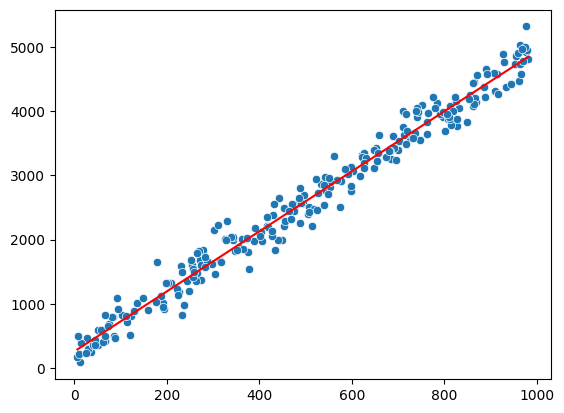

In [9]:
print(f"model slope: {model.coef_[0]:.2f}, model intercept: {model.intercept_:.2f}")
print(f"true slope: {true_slope:.2f}, true intercept: {true_intercept:.2f}")
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=model.predict(X), color='red')

## supervised learning example: classification

In [20]:
from sklearn.model_selection import train_test_split

y = passengers

X = taxis.copy()

# datetime to numeric
datetime_cols = X.select_dtypes(include=["datetime64[ns]"]).columns
for col in datetime_cols:
    X[col] = X[col].astype("int64")

# cateogrical to numeric
X = pd.get_dummies(X, drop_first=True)
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, stratify=y
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

scores = {
    "accuracy": accuracy_score(ytest, y_model),
    "precision": precision_score(ytest, y_model, average="weighted"),
    "recall": recall_score(ytest, y_model, average="weighted"),
    "f1": f1_score(ytest, y_model, average="weighted")
}
scores

C:\Users\thkle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.7218337218337219,
 'precision': 0.5290809425500107,
 'recall': 0.7218337218337219,
 'f1': 0.6106067452655795}

## unsupervised learning example: dimensionality

C:\Users\thkle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_isomap.py:362: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\thkle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


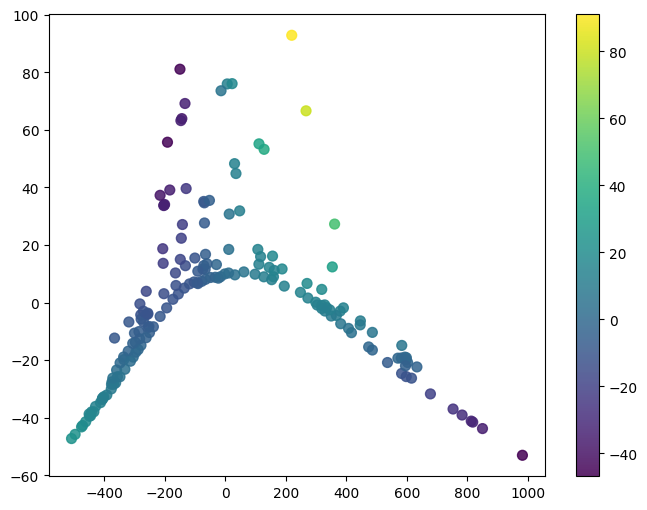

In [34]:
from sklearn.datasets import load_wine
from sklearn.manifold import Isomap

wine = load_wine()
mat = wine.data

iso = Isomap(n_components=3)
iso.fit(mat)
mat_transformed = iso.transform(mat)
mat_transformed.shape

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    mat_transformed[:, 0],
    mat_transformed[:, 1],
    c=mat_transformed[:, 2],
    cmap="viridis",
    s=50,
    alpha=0.85
)
plt.colorbar(sc)

## classification on digits

{'accuracy': 0.9320148331273177, 'precision': 0.9323955711106888, 'recall': 0.9320148331273177, 'f1': 0.9315527095791454}


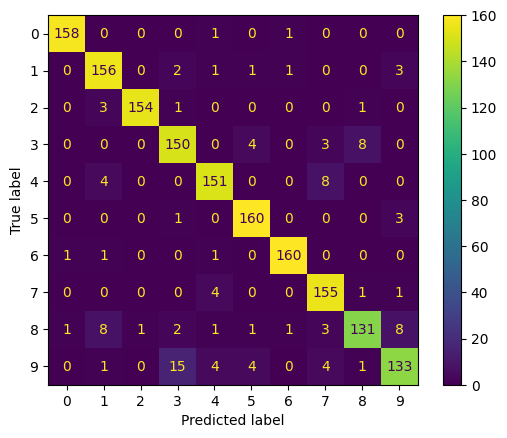

In [42]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

model = RandomForestClassifier()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, stratify=y)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

scores = {
    "accuracy": accuracy_score(y_test, predictions),
    "precision": precision_score(y_test, predictions, average="weighted"),
    "recall": recall_score(y_test, predictions, average="weighted"),
    "f1": f1_score(y_test, predictions, average="weighted")
}
print(scores)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mat = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=digits.target_names)
disp.plot()